## Check out the related blog post!
https://www.instagram.com/p/DYCTQJjiDBC/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Open the image and get the most frequent color to assume as background
img = Image.open('/content/bg.png')
img_small = img.resize((50, 50))
colors = img_small.getcolors(2500)
bg_color_rgb = max(colors, key=lambda x: x[0])[1]
bg_hex = '#%02x%02x%02x' % bg_color_rgb[:3]
print(f'Extracted background color: {bg_hex}')

Extracted background color: #13171b


#### Different pseudo-residuals serve different purposes

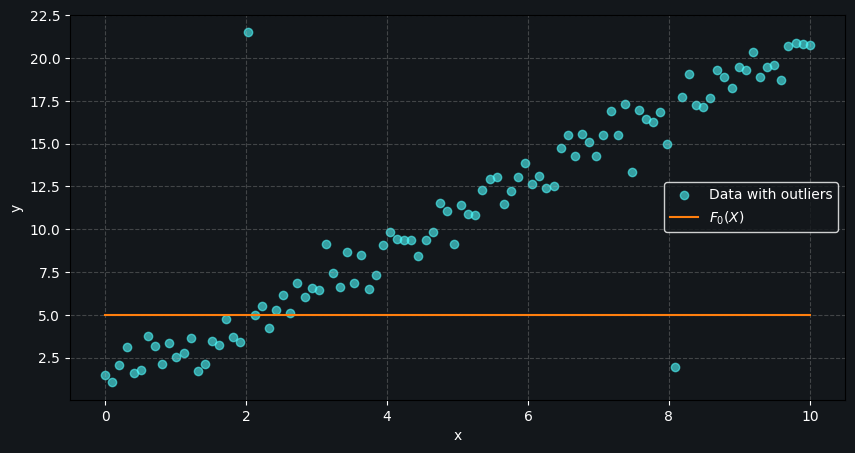

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
x = np.sort(np.linspace(0, 10, 100))
y = 2 * x + 1 + np.random.normal(0, 1, 100)

# Add outliers
y[20] += 15
y[80] -= 15

# Simple linear 'current' prediction to calculate residuals against
y_pred = np.repeat(x.mean(), x.shape[0])

fig, ax = plt.subplots(figsize=(10, 5))

# Apply background theme
fig.patch.set_facecolor(bg_hex)
ax.set_facecolor(bg_hex)

ax.scatter(x, y, alpha=0.6, label='Data with outliers', color='#4efafc')
ax.plot(x, y_pred, color='#ff7f0e', label=r'$F_0(X)$')

ax.set_xlabel('x', color='white')
ax.set_ylabel('y', color='white')
ax.tick_params(colors='white')

# Add white grid
ax.grid(True, linestyle='--', color='white', alpha=0.3)

legend = ax.legend(facecolor=bg_hex, edgecolor='white')
plt.setp(legend.get_texts(), color='white')

plt.show()

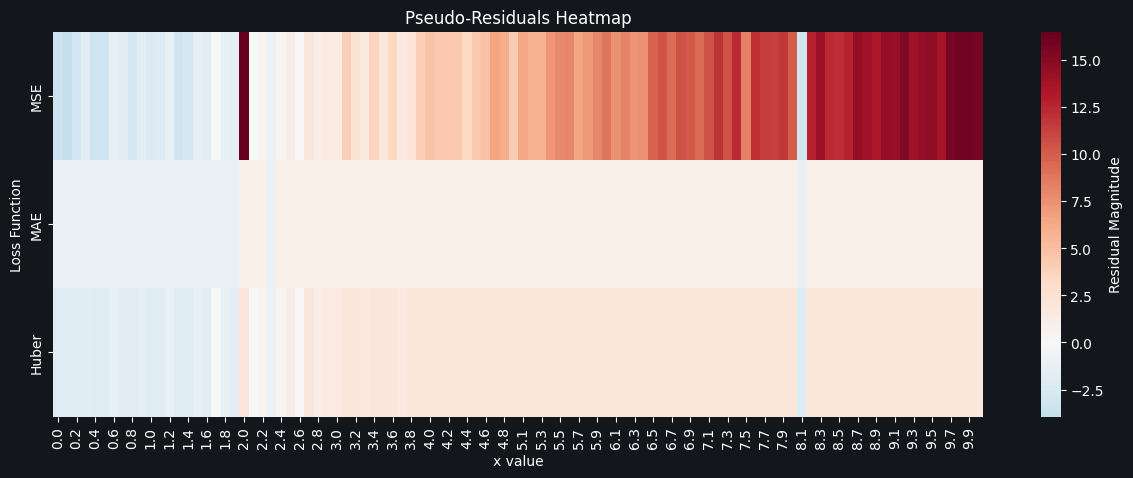

In [ ]:
def huber_gradient(y_true, y_pred, delta=1.5):
    diff = y_true - y_pred
    return np.where(np.abs(diff) <= delta, diff, delta * np.sign(diff))

res_mse = y - y_pred
res_mae = np.sign(y - y_pred)
res_huber = huber_gradient(y, y_pred, delta=2.0)

residual_data = pd.DataFrame({
    'x': np.round(x, 1),
    'MSE': res_mse,
    'MAE': res_mae,
    'Huber': res_huber
})

# Prepare for heatmap
heatmap_df = residual_data.set_index('x').T

fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor(bg_hex)

# Use seaborn heatmap and capture the returned axis for the colorbar
res_plot = sns.heatmap(heatmap_df, cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Residual Magnitude'})

# Style the colorbar (the 'legend' of the heatmap)
cbar = res_plot.collections[0].colorbar
cbar.set_label('Residual Magnitude', color='white')
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

ax.set_title('Pseudo-Residuals Heatmap', color='white')
ax.set_ylabel('Loss Function', color='white')
ax.set_xlabel('x value', color='white')
ax.tick_params(colors='white')

plt.show()

#### Implementing GBM's (Gradient Boosting Classifier) algorithm

In [ ]:
from abc import ABC, abstractmethod
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class GBM(ABC):
    def __init__(self, lr=0.1, M=100, max_depth=1, post_correction=False):
        self.nu = lr
        self.M = M
        self.max_depth = max_depth
        self.weak_learners = []
        self.f0 = None
        self.use_post_correction = post_correction

    @abstractmethod
    def compute_f0(self, y):
        """Initial prediction"""
        pass

    @abstractmethod
    def pseudo_residual(self, y, y_pred):
        """Negative gradient"""
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def post_correction(self, X, y, y_pred, tree):
        """Update tree leaf values"""
        pass

    def fit(self, X, y):
        self.f0 = self.compute_f0(y)
        y_pred = np.full(y.shape, self.f0)

        for m in range(self.M):
            residuals = self.pseudo_residual(y, y_pred)
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)

            if self.use_post_correction:
                self.post_correction(X, y, y_pred, tree)

            self.weak_learners.append(tree)
            y_pred += self.nu * tree.predict(X)

    def predict_score(self, X):
        y_pred = np.full(X.shape[0], self.f0)
        for weak_learner in self.weak_learners:
            y_pred += self.nu * weak_learner.predict(X)
        return y_pred

class GBC(GBM):
    def compute_f0(self, y):
        p = np.mean(y == 1)
        return np.log(p / (1 - p))

    def pseudo_residual(self, y, y_pred):
        p = 1 / (1 + np.exp(-y_pred))
        return y - p

    def post_correction(self, X, y, y_pred, tree):
        # Get indices of the leaf nodes for each sample
        leaf_indices = tree.apply(X)
        p = 1 / (1 + np.exp(-y_pred))

        # Access internal tree structure
        tree_ = tree.tree_

        for leaf in np.unique(leaf_indices):
            # Explicitly verify this is a terminal node
            if tree_.children_left[leaf] == -1 and tree_.children_right[leaf] == -1:
                mask = (leaf_indices == leaf)
                numerator = np.sum(y[mask] - p[mask])
                denominator = np.sum(p[mask] * (1 - p[mask]))

                # Update the leaf value (Newton-Raphson step)
                if denominator > 1e-9:
                    tree_.value[leaf, 0, 0] = numerator / denominator

    def predict(self, X):
        scores = self.predict_score(X)
        return 1 / (1 + np.exp(-scores))

#### How does Newton's method work in `GBC.post_correction()`?

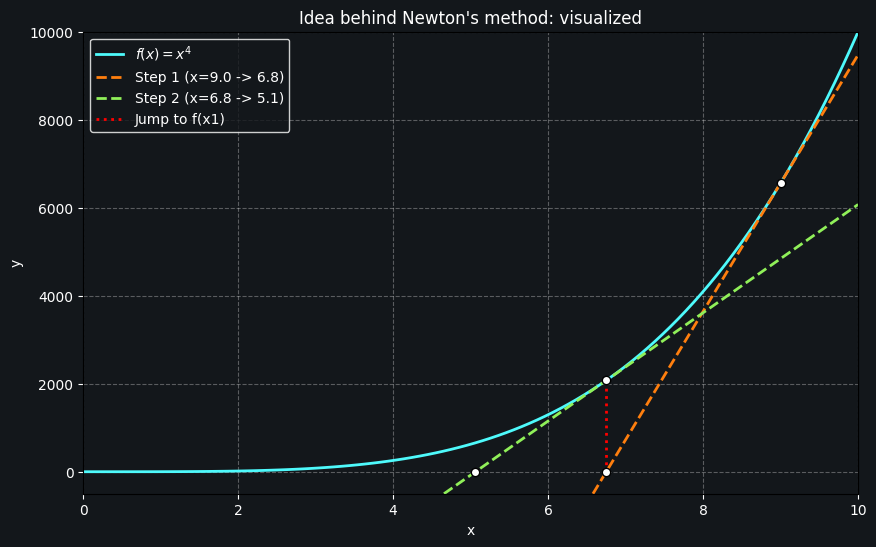

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(bg_hex)
ax.set_facecolor(bg_hex)

x_range = np.linspace(0, 10, 100)
y_range = x_range ** 4
ax.plot(x_range, y_range, color='#4efafc', label=r'$f(x)=x^4$', linewidth=2)
ax.set_xlim(0, 10)
ax.set_ylim(-500, 10000)

# Iteration 1
x0 = 9
f_x0 = x0 ** 4
x1 = x0 - (x0 ** 4 / (4 * x0 ** 3))

# Iteration 2
f_x1 = x1 ** 4
x2 = x1 - (x1 ** 4 / (4 * x1 ** 3))

# Plot Tangent 1
ax.axline((x0, f_x0), (x1, 0), color='#ff7f0e', linewidth=2, linestyle='--', label=f'Step 1 (x={x0:.1f} -> {x1:.1f})')

# Plot Tangent 2
ax.axline((x1, f_x1), (x2, 0), color='#90f059', linewidth=2, linestyle='--', label=f'Step 2 (x={x1:.1f} -> {x2:.1f})')

# Add red line pointing to the next f_x1
ax.vlines(x1, 0, f_x1, color='red', linestyle=':', linewidth=2, label='Jump to f(x1)')

# Mark the points
ax.scatter([x0, x1, x1, x2], [f_x0, 0, f_x1, 0], color='white', zorder=5, edgecolor='black')

ax.set_xlabel('x', color='white')
ax.set_ylabel('y', color='white')
ax.tick_params(colors='white')
ax.grid(True, linestyle='--', color='white', alpha=0.3)

legend = ax.legend(facecolor=bg_hex, edgecolor='white')
plt.setp(legend.get_texts(), color='white')

plt.title('Idea behind Newton\'s method: visualized', color='white')

plt.show()

#### Generating train data for the GBC

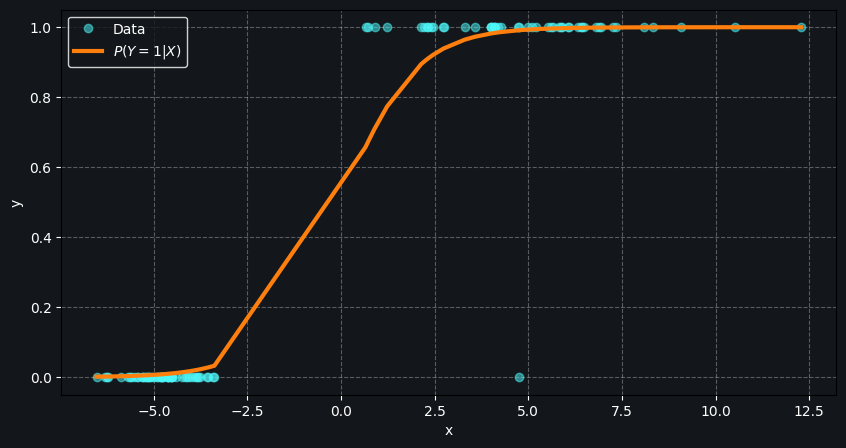

In [ ]:
from sklearn.datasets import make_classification
sigmoid = lambda t: 1 / (1 + np.exp(-t))

X, y = make_classification(
    random_state=42, n_features=1,
    n_informative=1, n_redundant=0,
    n_clusters_per_class=1
  )

X *= 5

# Sort X to ensure the line plot is smooth
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]
p_sorted = sigmoid(X_sorted)

# plotting true distribution
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(bg_hex)
ax.set_facecolor(bg_hex)

# Scatter the original data, but plot the line using sorted values
ax.plot(X, y, 'o', color='#4efafc', label='Data', alpha=0.5)
ax.plot(X_sorted, p_sorted, color='#ff7f0e', linewidth=3, label=r'$P(Y=1|X)$')

ax.set_xlabel('x', color='white')
ax.set_ylabel('y', color='white')
ax.tick_params(colors='white')

# Add white grid
ax.grid(True, linestyle='--', color='white', alpha=0.3)

legend = ax.legend(facecolor=bg_hex, edgecolor='white')
plt.setp(legend.get_texts(), color='white')

plt.show()

#### Training GBC on $M=25$ **without** post correction

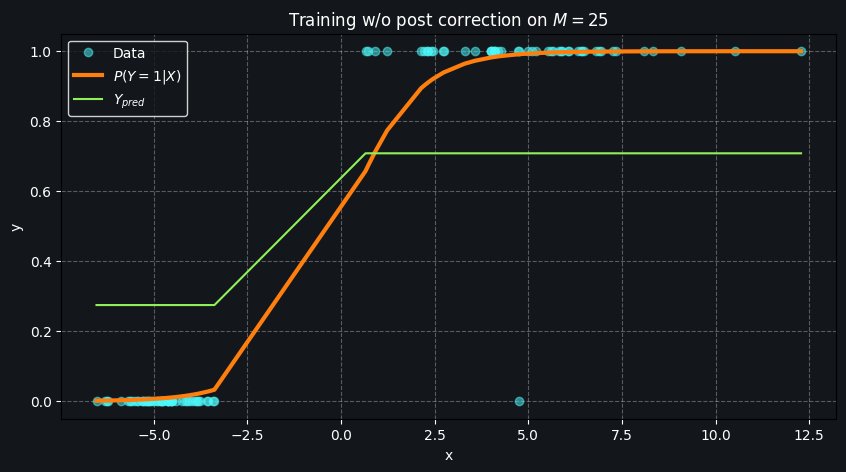

In [ ]:
gmb_classifier = GBC(lr=0.1, M=25, max_depth=1)
gmb_classifier.fit(X, y)
Y_pred = gmb_classifier.predict(X_sorted)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(bg_hex)
ax.set_facecolor(bg_hex)

ax.plot(X, y, 'o', color='#4efafc', label='Data', alpha=0.5)
ax.plot(X_sorted, p_sorted, color='#ff7f0e', linewidth=3, label=r'$P(Y=1|X)$')
ax.plot(X_sorted, Y_pred, color='#90f059', label=r'$Y_{pred}$')

ax.set_xlabel('x', color='white')
ax.set_title(r'Training w/o post correction on $M=25$', color='white')
ax.set_ylabel('y', color='white')
ax.tick_params(colors='white')

# Add white grid
ax.grid(True, linestyle='--', color='white', alpha=0.3)

legend = ax.legend(facecolor=bg_hex, edgecolor='white')
plt.setp(legend.get_texts(), color='white')

plt.show()

#### Training GBC on $M=25$ **WITH** post correction

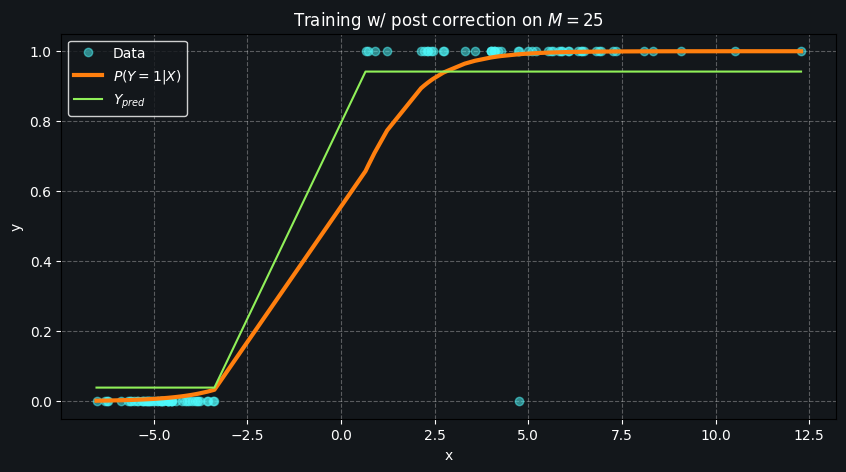

In [ ]:
gmb_classifier = GBC(lr=0.1, M=25, max_depth=1, post_correction=True)
gmb_classifier.fit(X, y)
Y_pred = gmb_classifier.predict(X_sorted)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(bg_hex)
ax.set_facecolor(bg_hex)

ax.plot(X, y, 'o', color='#4efafc', label='Data', alpha=0.5)
ax.plot(X_sorted, p_sorted, color='#ff7f0e', linewidth=3, label=r'$P(Y=1|X)$')
ax.plot(X_sorted, Y_pred, color='#90f059', label=r'$Y_{pred}$')

ax.set_xlabel('x', color='white')
ax.set_title(r'Training w/ post correction on $M=25$', color='white')
ax.set_ylabel('y', color='white')
ax.tick_params(colors='white')

# Add white grid
ax.grid(True, linestyle='--', color='white', alpha=0.3)

legend = ax.legend(facecolor=bg_hex, edgecolor='white')
plt.setp(legend.get_texts(), color='white')

plt.show()